# ME 323 Virtual Lab A
## Bayesian Design Foundations for 3D-Printed I-Beams

### Estimated time
About 65–90 minutes

This lab asks:

**If we can only afford a small number of beam tests, which beam should we test next?**

You will learn to use a predictive model when data are sparse. We will not turn you into a machine learning specialist.

### Memo connection
Save your figures and results as you work.
Answer the interpretation questions in your **lab memo**.

### Background for students who want more
If you want a fuller treatment after class, look at:
- Predictive Science Lab: *Gaussian Process Regression*  
  https://predictivesciencelab.github.io/data-analytics-se/gaussian_process_regression.html
- Bilionis text, Chapters 21–23:
  - *Gaussian Process Regression: Priors on Function Spaces*
  - *Gaussian Process Regression: Conditioning on Data*
  - *Bayesian Global Optimization*

## Learning goals

By the end of this virtual lab, you should be able to:

- explain what a **surrogate model** is and why it is useful in an expensive testing problem
- explain the difference between **epistemic** and **aleatory** uncertainty
- explain how a Gaussian Process updates after seeing beam data
- explain how Bayesian Optimization chooses the next test by balancing **exploration** and **exploitation**
- compare **maximum upper interval** and **Expected Improvement**, 2 methods for design selection with limited data
- use a simple GP-based predictive model to recommend a first I-beam design to test

## PART A. Framing the engineering challenge

We want to design a better 3D-printed I-beam for three-point bending.

Each design is described by geometry variables such as:
- web thickness, **b**
- web height, **h**
- flange width, **B**
- total height, **H**

In this first lab, we will mostly work with **b** and **H** through a small beam dataset.

The key engineering reality is this:

- physical beam tests take time
- printing and testing budgets are limited
- the design space is continuous
- we do not know the true strength-to-weight function ahead of time
- we still need to choose a next beam intelligently

So the practical question is:

> **Given the beam data we already have, where should we test next?**

## PART B. Why I-beams?

I-beams are a natural design problem because geometry matters a lot.

Very loosely:
- placing more material away from the neutral axis often helps bending efficiency
- changing web thickness changes weight, shear capacity, and likely failure behavior
- changing beam height changes bending leverage, stiffness trends, and sometimes instability risk

That means I-beams create real design tradeoffs instead of a trivial “bigger is always better” problem.

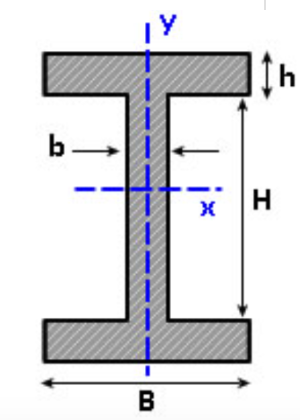

## PART C. Definitions and mental models

### Surrogate model
A **surrogate model** stands in for the unknown beam-performance function. It represents our best prediction based on limited data.

### Strength model
A **strength model** or **predictive model** maps beam design variables to predicted performance, such as strength-to-weight ratio.

### Predictive mean
The **predictive mean** is the model's current best estimate of likely performance at a design point.

### Epistemic uncertainty
**Epistemic uncertainty** stems from limited knowledge. Here, it comes from testing too few beams across the design space.

- Epistemic uncertainty shrinks when we collect more data.
- Bayesian Optimization uses it to decide where to test next.

### Aleatory uncertainty
**Aleatory uncertainty** represents irreducible variability in the observations. Repeated prints and tests vary.

- Aleatory uncertainty captures real scatter in observations.
- Epistemic uncertainty captures what the model lacks.

### Noise
In this notebook, the GP noise assumption represents the **aleatory** scatter.

### Covariance
Covariance indicates how strongly two design points move together. Geometrically similar beam designs exhibit related behavior.

### Exploration vs exploitation
- **Exploitation** tests where the model predicts strong performance.
- **Exploration** tests where the model lacks certainty.

### Acquisition function
An **acquisition function** dictates which beam to test next.

<!-- Section removed to streamline notebook -->

In [2]:
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF

plt.rcParams["figure.dpi"] = 130
np.random.seed(2)


## PART D. Load beam data

This notebook pulls the beam data directly from GitHub.

Expected columns used here:
- `b_web_mm`
- `H_web_mm`
- `Strength N`

Optional columns:
- `Beam Number`
- `Str/w N/g`
- `weight g`

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/andrewvoss8-boop/"
    "core-me-data-science-activities-public/main/data/I_beam_data_2var.csv"
)

# Load data directly from the URL
df_full = pd.read_csv(DATA_URL)

keep_cols = [c for c in ["Beam Number", "b_web_mm", "H_web_mm", "Strength N", "Str/w N/g", "weight g"] if c in df_full.columns]
df_full = df_full[keep_cols].dropna(subset=["b_web_mm", "H_web_mm", "Strength N"]).copy()

beam_data = df_full.rename(columns={
    "b_web_mm": "b_mm",
    "H_web_mm": "H_mm",
    "Str/w N/g": "strength_to_weight",
    "Strength N": "strength_N",
    "weight g": "weight_g"
}).copy()

if "strength_to_weight" not in beam_data.columns and {"strength_N", "weight_g"}.issubset(beam_data.columns):
    beam_data["strength_to_weight"] = beam_data["strength_N"] / beam_data["weight_g"]

print("Loaded beam data from GitHub")
beam_data.head()


Loaded beam data from GitHub


,Beam Number,b_mm,H_mm,strength_N,strength_to_weight,weight_g
0,1,4.632,21.681,884.85,21.450909,41.25
1,2,2.832,18.694,1078.17,25.567228,42.17
2,3,6.778,17.522,1940.97,29.953241,64.80
3,4,2.306,15.863,1501.89,30.097996,49.90
4,5,7.342,19.837,1776.36,28.655590,61.99


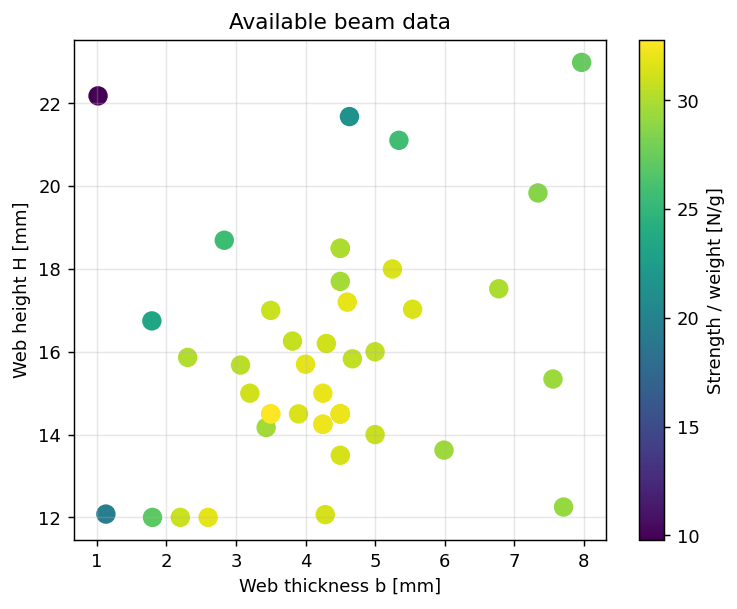

In [4]:
plt.figure(figsize=(6.6, 5.0))
sc = plt.scatter(
    beam_data["b_mm"],
    beam_data["H_mm"],
    c=beam_data["strength_to_weight"],
    s=95
)
plt.colorbar(sc, label="Strength / weight [N/g]")
plt.xlabel("Web thickness b [mm]")
plt.ylabel("Web height H [mm]")
plt.title("Available beam data")
plt.grid(alpha=0.3)
plt.show()


### Question 1
In your memo, briefly describe what this dataset tells you **and what it still does not tell you** about the design space.

## PART E. Sources of noise and variability in this lab

In this lab, the observation noise is not just “sensor error.”  
Several effects can make repeated measurements at the **same nominal beam design** come out differently.

### Main sources we will consider

1. **Test-to-test variability**  
   Small differences in alignment, support contact, where failure starts, and how the specimen seats in the test setup.

2. **Material / batch / color variability**  
   Different spools, material batches, or colors can behave slightly differently even at the same nominal geometry.

3. **Print-to-print process / microstructure variability**  
   Small changes in temperature history, bonding, porosity, or local print quality can shift strength from one print to the next.

4. **Measurement-system noise**  
   The load frame and measurement system also add some uncertainty.

### Suggested starting estimates for this course
These are **engineering starting estimates** for this notebook.  
They are not universal truths. If replicate test data become available, those should replace these guesses.

In [5]:
noise_table = pd.DataFrame({
    "Source": [
        "Test-to-test variability",
        "Batch / color variability",
        "Print process / microstructure variability",
        "Measurement-system noise"
    ],
    "Suggested range (% of measured response)": [
        "1–3%",
        "1–3%",
        "2–5%",
        "0.5–1%"
    ],
    "How to think about it": [
        "setup and failure-initiation scatter",
        "may partly act like a batch effect",
        "interlayer bonds, porosity, local print quality",
        "instrument and readout scatter"
    ]
})

noise_table


,Source,Suggested range (% of measured response),How to think about it
0,Test-to-test variability,1–3%,setup and failure-initiation scatter
1,Batch / color variability,1–3%,may partly act like a batch effect
2,Print process / microstructure variability,2–5%,"interlayer bonds, porosity, local print quality"
3,Measurement-system noise,0.5–1%,instrument and readout scatter


### How these estimates inform the model

For this notebook, we will compare three relative noise assumptions:
- **low:** 1%
- **moderate:** 3% (a believable middle case)
- **high:** 5% (a higher case that won't totally flatten the GP)

The **moderate** case is our best first engineering guess.
*(Note: A larger assumed noise level, such as 8%, can sometimes improve predictive performance by smoothing the model and reducing overfitting. Even if that larger value is better interpreted as an effective regularization choice than as a literal estimate of lab scatter, we have left it as an optional extension to try later.)*

In the GP fit below, we model the target in **log space**.  
So a relative noise assumption $r$ becomes approximately

$$
\alpha \approx r^2
$$

in the GP fit.

Also note:
- **epistemic uncertainty** is what the model can reduce by learning from more beam tests
- **aleatory uncertainty** is the observation noise that does not disappear just because we add one more point

## PART F. A beam-based 1D example

Instead of using an abstract toy function, we will start with a **beam-based 1D slice**.

Below, we automatically choose a rough slice of the data with similar heights and then look at how strength-to-weight varies with **web thickness b**.

This is not the whole design problem.  
It is just a simpler window into the problem so you can see the GP and BO ideas clearly.

In [6]:
def choose_slice(data, min_points=5):
    unique_H = np.sort(data["H_mm"].unique())
    center = np.median(unique_H)
    for tol in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]:
        mask = np.abs(data["H_mm"] - center) <= tol
        sliced = data.loc[mask].sort_values("b_mm").reset_index(drop=True)
        if len(sliced) >= min_points and sliced["b_mm"].nunique() >= 10:
            return sliced, center, tol
    return data.sort_values("b_mm").reset_index(drop=True), center, None

slice_data, H_center, H_tol = choose_slice(beam_data)

print(f"Slice center H ≈ {H_center}")
print(f"Tolerance used: {H_tol}")
slice_data


Slice center H ≈ 16.0
Tolerance used: 1.0


,Beam Number,b_mm,H_mm,strength_N,strength_to_weight,weight_g
0,7,1.791,16.746,1025.94,23.274501,44.08
1,4,2.306,15.863,1501.89,30.097996,49.90
2,UCB 3 param,3.066,15.680,1618.56,30.435502,53.18
3,34.2,3.200,15.000,1768.67,31.149524,56.78
4,19,3.500,17.000,1580.33,30.932276,51.09
5,BH,3.813,16.258,1696.40,30.770905,55.13
6,23,4.000,15.700,1825.14,31.846798,57.31
7,25,4.250,15.000,1973.92,32.033755,61.62
8,18,4.300,16.200,1780.66,31.097800,57.26
9,DHR,4.674,15.831,1833.30,30.544818,60.02


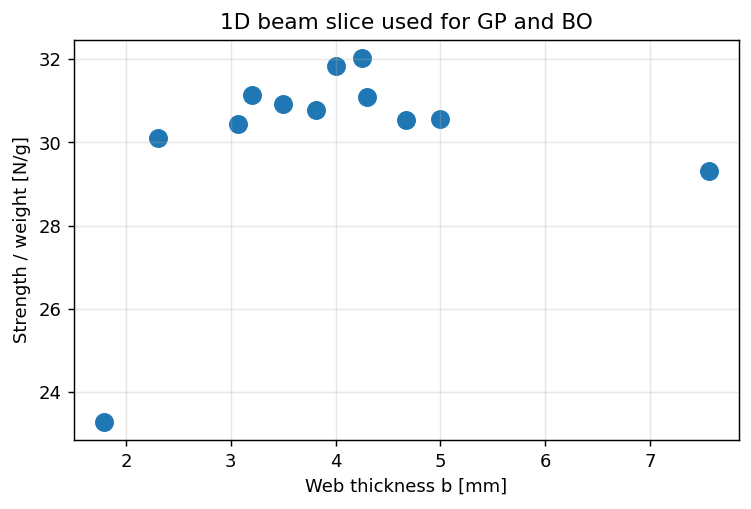

In [7]:
plt.figure(figsize=(6.6, 4.0))
plt.scatter(slice_data["b_mm"], slice_data["strength_to_weight"], s=90)
plt.xlabel("Web thickness b [mm]")
plt.ylabel("Strength / weight [N/g]")
plt.title("1D beam slice used for GP and BO")
plt.grid(alpha=0.3)
plt.show()


## PART G. What the Gaussian Process is doing

A Gaussian Process is a probability model over possible functions.

For this lab, the important idea is:

> Before seeing data, we allow many plausible strength models.  
> After seeing data, some become more believable than others.

In practical terms, the GP combines:
- a **mean function**: our baseline trend assumption
- a **covariance kernel**: a similarity rule saying nearby designs should tend to behave more similarly than distant ones

After conditioning on data, the GP gives:
- a **posterior mean**: our current best predicted trend
- a **posterior variance**: our current uncertainty

For a test point $x'$, the GP computes a predictive mean and variance using the observed beam data and the covariance relationships between the new point and old points. In matrix form, that update looks like

$$
\mu_n(x') = m(x') + k(x',X)\left(K(X,X)+\sigma^2 I\right)^{-1}(y-m(X))
$$

and

$$
\sigma_n^2(x') = k(x',x') - k(x',X)\left(K(X,X)+\sigma^2 I\right)^{-1}k(X,x').
$$

You do **not** need to memorize those equations for this lab.

What matters is the interpretation:
- if a new point is close to known data, the GP learns strongly from nearby observations
- if a point is far from existing data, uncertainty stays larger
- if the kernel assumes smoother behavior, the predictive model becomes smoother

## PART H. Fit a 1D Gaussian Process to the beam slice

To make the noise assumption behave sensibly, we fit the GP to

\[
z = \log(	ext{strength-to-weight}).
\]

That way, a 1%, 5%, or 8% noise assumption is treated as a **relative** noise level rather than a fixed noise size in raw N/g units.

We then convert the predictions back to the original N/g scale for plotting.

In [8]:
X1 = slice_data[["b_mm"]].values.astype(float)
y1 = slice_data["strength_to_weight"].values.astype(float)

def fit_log_gp(X, y, rel_noise, length_scale_init=1.0):
    z = np.log(y)
    z_mean = z.mean()
    z_centered = z - z_mean

    alpha = rel_noise**2

    kernel = C(1.0, (1e-3, 1e3)) * RBF(
        length_scale=length_scale_init,
        length_scale_bounds=(1e-2, 10.0)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha,
        normalize_y=False,
        random_state=0,
        n_restarts_optimizer=5
    )
    gp.fit(X, z_centered)

    return gp, z_mean

def predict_log_gp(gp, z_mean, X_plot, rel_noise):
    mu_z_centered, std_epi_z = gp.predict(X_plot, return_std=True)
    mu_z = mu_z_centered + z_mean

    std_total_z = np.sqrt(std_epi_z**2 + rel_noise**2)

    mean_y = np.exp(mu_z)
    lo_epi_y = np.exp(mu_z - 2*std_epi_z)
    hi_epi_y = np.exp(mu_z + 2*std_epi_z)

    lo_total_y = np.exp(mu_z - 2*std_total_z)
    hi_total_y = np.exp(mu_z + 2*std_total_z)

    return {
        "mu_z": mu_z,
        "std_epi_z": std_epi_z,
        "std_total_z": std_total_z,
        "mean_y": mean_y,
        "lo_epi_y": lo_epi_y,
        "hi_epi_y": hi_epi_y,
        "lo_total_y": lo_total_y,
        "hi_total_y": hi_total_y,
    }

baseline_noise_frac = 0.03
gp1d, zmean1d = fit_log_gp(X1, y1, rel_noise=baseline_noise_frac, length_scale_init=1.0)

b_plot = np.linspace(float(beam_data["b_mm"].min()), float(beam_data["b_mm"].max()), 500).reshape(-1, 1)
pred1d = predict_log_gp(gp1d, zmean1d, b_plot, rel_noise=baseline_noise_frac)

print("Learned 1D kernel:")
print(gp1d.kernel_)
print(f"Baseline relative aleatory noise assumption = {baseline_noise_frac:.0%}")

Learned 1D kernel:
0.0984**2 * RBF(length_scale=0.454)
Baseline relative aleatory noise assumption = 3%


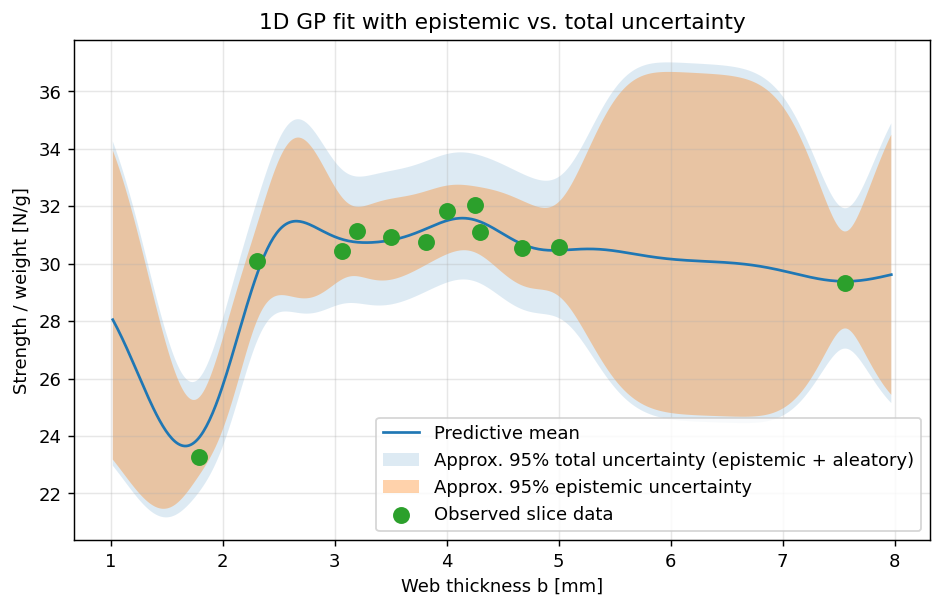

In [9]:
plt.figure(figsize=(8.5, 5.0))
plt.plot(b_plot, pred1d["mean_y"], label="Predictive mean")
plt.fill_between(
    b_plot.ravel(),
    pred1d["lo_total_y"],
    pred1d["hi_total_y"],
    alpha=0.15,
    label="Approx. 95% total uncertainty (epistemic + aleatory)"
)
plt.fill_between(
    b_plot.ravel(),
    pred1d["lo_epi_y"],
    pred1d["hi_epi_y"],
    alpha=0.35,
    label="Approx. 95% epistemic uncertainty"
)
plt.scatter(X1, y1, s=70, zorder=3, label="Observed slice data")
plt.xlabel("Web thickness b [mm]")
plt.ylabel("Strength / weight [N/g]")
plt.title("1D GP fit with epistemic vs. total uncertainty")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### What to notice
When you look at the figure, ask:

- Where is the model confident?
- Where is it uncertain because of limited data?
- How wide is the extra observation spread caused by aleatory noise?
- Are the strongest predicted regions the same as the most uncertain regions?

These are the questions Bayesian Optimization tries to use productively.


### Question 2
In your memo, explain the difference between the **epistemic** uncertainty band and the **total** uncertainty band in this beam-design context.

## PART I. Noise activity: what changes when we assume noisier data?

Below, we compare low, moderate, and high noise assumptions.

This section is not saying that the largest noise value is “the truth.”  
It is partly a sensitivity study:
- what changes if we trust the data a lot?
- what changes if we smooth more aggressively?

In [10]:
noise_fracs = [0.01, 0.03, 0.05]

preds_noise = {}
models_noise = {}

for nf in noise_fracs:
    gp_n, zmean_n = fit_log_gp(X1, y1, rel_noise=nf, length_scale_init=1.0)
    pred_n = predict_log_gp(gp_n, zmean_n, b_plot, rel_noise=nf)
    preds_noise[nf] = pred_n
    models_noise[nf] = (gp_n, zmean_n)

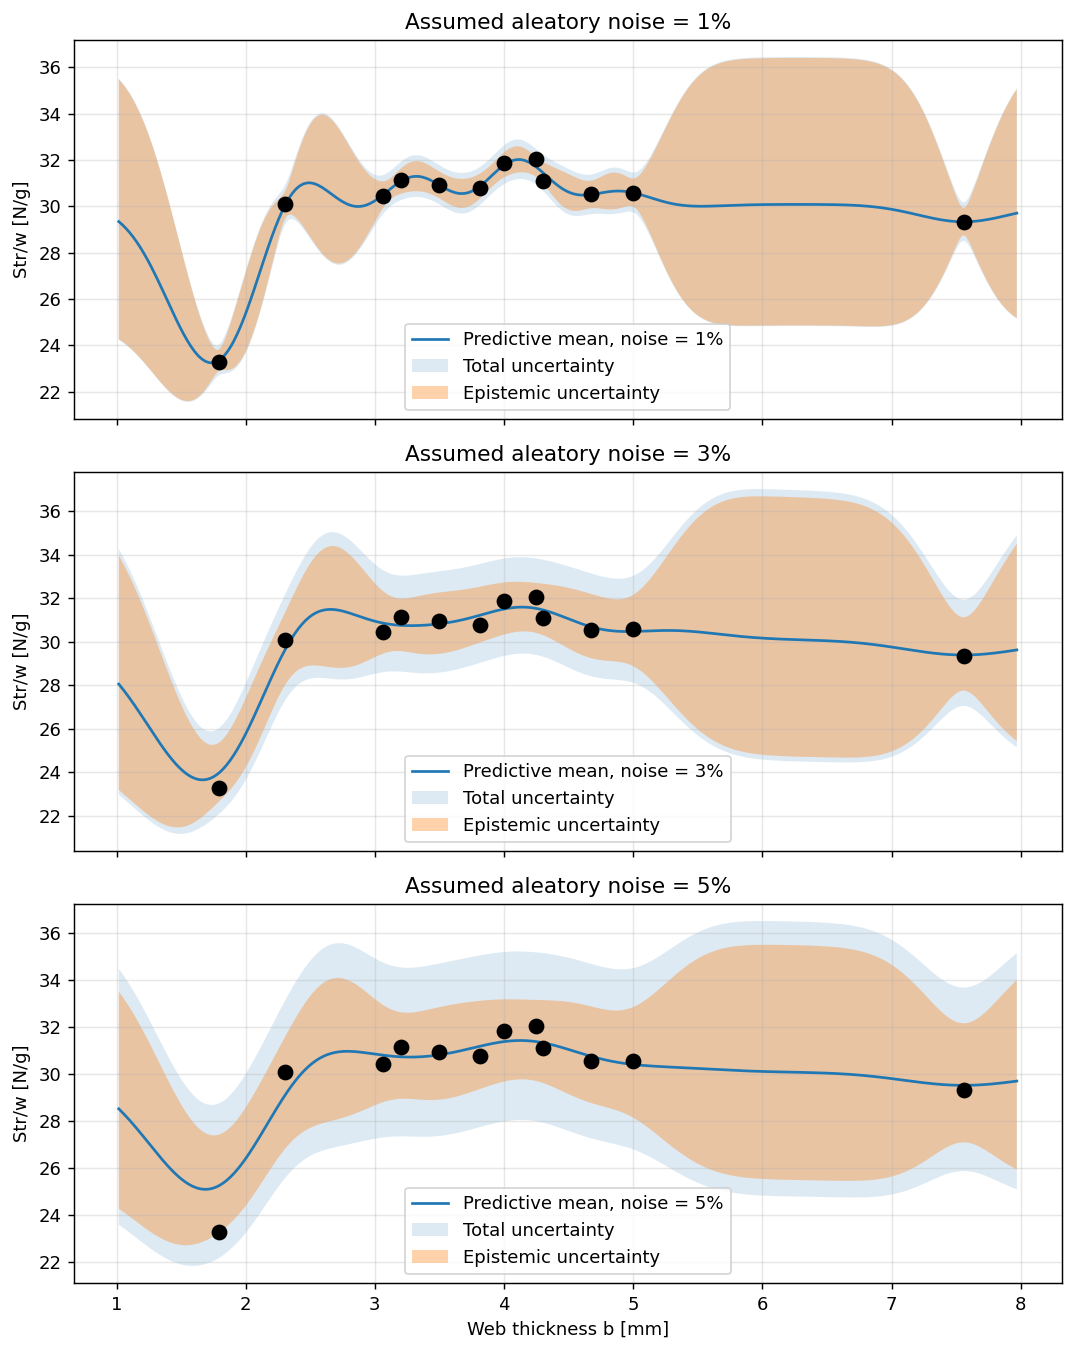

In [11]:
fig, axes = plt.subplots(len(noise_fracs), 1, figsize=(8.5, 10.5), sharex=True)

for ax, nf in zip(axes, noise_fracs):
    pred_n = preds_noise[nf]

    ax.plot(b_plot, pred_n["mean_y"], label=f"Predictive mean, noise = {int(nf*100)}%")
    ax.fill_between(
        b_plot.ravel(),
        pred_n["lo_total_y"],
        pred_n["hi_total_y"],
        alpha=0.15,
        label="Total uncertainty"
    )
    ax.fill_between(
        b_plot.ravel(),
        pred_n["lo_epi_y"],
        pred_n["hi_epi_y"],
        alpha=0.35,
        label="Epistemic uncertainty"
    )
    ax.scatter(X1, y1, s=60, zorder=3, color="black")
    ax.set_ylabel("Str/w [N/g]")
    ax.set_title(f"Assumed aleatory noise = {nf:.0%}")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Web thickness b [mm]")
plt.tight_layout()
plt.show()


### Question 3
Look at the three fits and compare them.

Questions to answer in your memo:
- Which fit hugs the data most tightly?
- Which fit treats the data as noisier measurements of an underlying trend?
- How does the epistemic band change?
- How does the total uncertainty band change?
- Which noise assumption seems most believable for this lab?
- In which case does smoothing seem helpful?

## PART J. Why mean-only selection fails

Testing the beam with the highest predicted mean constitutes **pure exploitation**.

This rule risks trapping the search near a local optimum. It ignores uncertain regions that contain better designs.

Bayesian Optimization uses **sequential information acquisition** instead.

## PART K. A simple Bayesian Optimization rule: maximum upper interval (MUI)

For this lab, we first use a simple upper-interval style acquisition rule:

$$
a(x) = \mu(x) + \psi \sigma(x)
$$

where:
- $\mu(x)$ = predictive mean in log space
- $\sigma(x)$ = **epistemic** predictive standard deviation in log space
- $\psi$ controls how exploratory the rule is

Interpretation:
- **small $\psi$** → more exploitation
- **large $\psi$** → more exploration

In [26]:
def mui(mu, sigma, psi):
    return mu + psi * sigma

def build_1d_candidates(observed_x, xmin, xmax, step=0.05):
    candidates = np.round(np.arange(xmin, xmax + step/2, step), 4)
    keep = []
    for c in candidates:
        if np.min(np.abs(observed_x.ravel() - c)) > step * 0.45:
            keep.append(c)
    return np.array(keep).reshape(-1, 1)

X1_candidates = build_1d_candidates(X1, float(beam_data["b_mm"].min()), float(beam_data["b_mm"].max()), step=0.05)
pred1d_cand = predict_log_gp(gp1d, zmean1d, X1_candidates, rel_noise=baseline_noise_frac)

def recommend_mui_1d(psi):
    acq = mui(pred1d_cand["mu_z"], pred1d_cand["std_epi_z"], psi)
    idx = np.argmax(acq)
    return {
        "method": "MUI",
        "dial": psi,
        "b_mm": float(X1_candidates[idx, 0]),
        "pred_mean": float(pred1d_cand["mean_y"][idx]),
        "epistemic_std_log": float(pred1d_cand["std_epi_z"][idx]),
        "acq": float(acq[idx])
    }

def plot_mui_for_psi(psi):
    acq_plot = mui(pred1d["mu_z"], pred1d["std_epi_z"], psi)
    idx_plot = np.argmax(acq_plot)
    b_next = float(b_plot[idx_plot, 0])

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axes[0].plot(b_plot, pred1d["mean_y"], label="Predictive mean")
    axes[0].fill_between(
        b_plot.ravel(), pred1d["lo_total_y"], pred1d["hi_total_y"],
        alpha=0.15, label="Total uncertainty"
    )
    axes[0].fill_between(
        b_plot.ravel(), pred1d["lo_epi_y"], pred1d["hi_epi_y"],
        alpha=0.35, label="Epistemic uncertainty"
    )
    axes[0].scatter(X1, y1, s=70, zorder=3, label="Observed slice data")
    axes[0].axvline(b_next, linestyle="--", label=f"Suggested next b = {b_next:.2f} mm")
    axes[0].set_ylabel("Strength / weight [N/g]")
    axes[0].set_title(f"1D GP with MUI, psi = {psi}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(b_plot, acq_plot, label="MUI acquisition")
    axes[1].axvline(b_next, linestyle="--", label=f"Suggested next b = {b_next:.2f} mm")
    axes[1].set_xlabel("Web thickness b [mm]")
    axes[1].set_ylabel("Acquisition value")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## PART L. Explore what changes when you change psi

Run the next cells with different values of `psi`.

Suggested values:
- `psi = 0.0`
- `psi = 1.5`
- `psi = 5.0`

These are intentionally spread out so you can see meaningful differences in the recommendation when the exploitation/exploration dial changes.

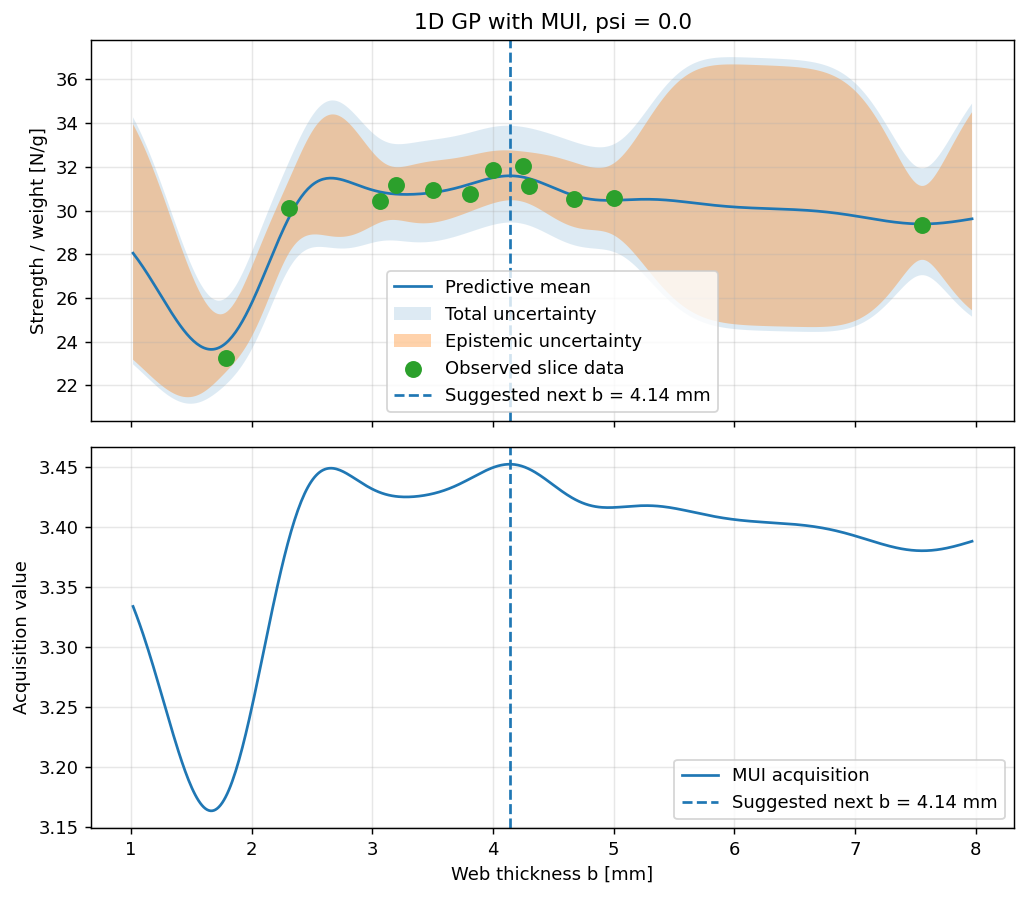

{'method': 'MUI', 'dial': 0.0, 'b_mm': 4.117, 'pred_mean': 31.584222922956336, 'epistemic_std_log': 0.018125435185149506, 'acq': 3.452657721323818}


In [27]:
psi = 0.0
plot_mui_for_psi(psi)
print(recommend_mui_1d(psi))

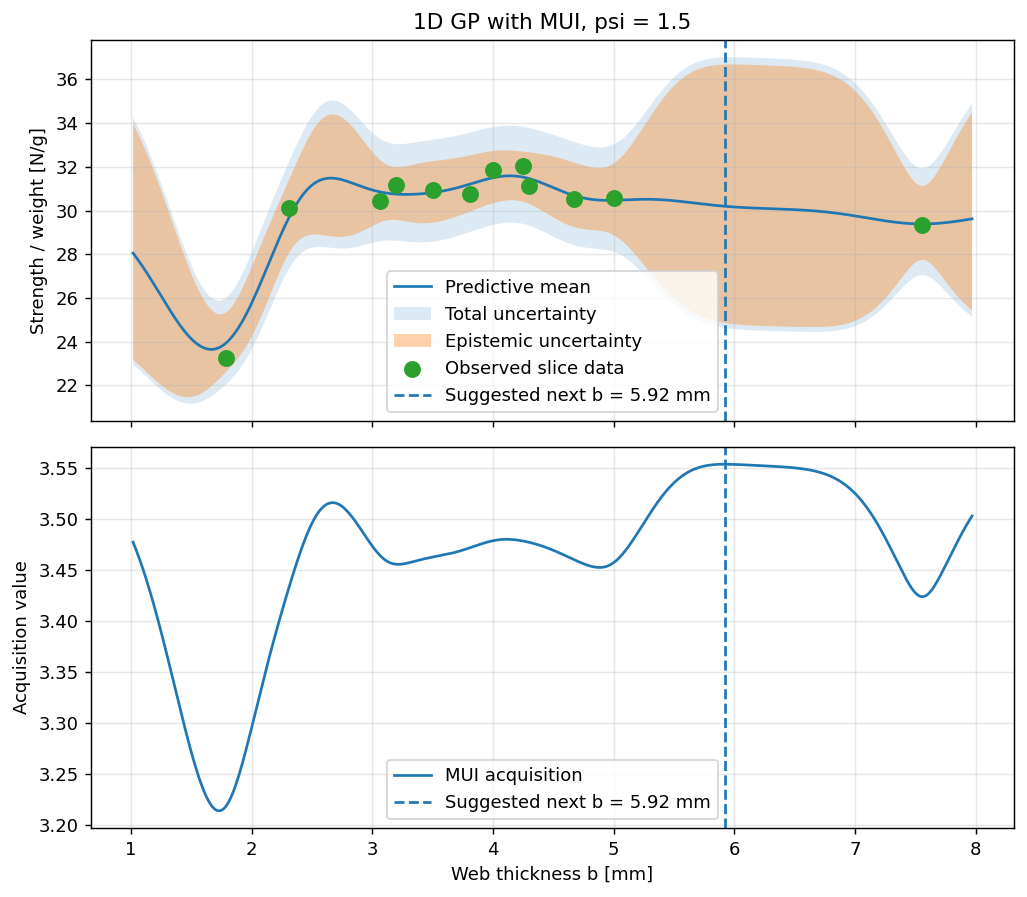

{'method': 'MUI', 'dial': 1.5, 'b_mm': 5.917, 'pred_mean': 30.1960392182509, 'epistemic_std_log': 0.09716412942662538, 'acq': 3.5534569582060778}


In [28]:
psi = 1.5
plot_mui_for_psi(psi)
print(recommend_mui_1d(psi))

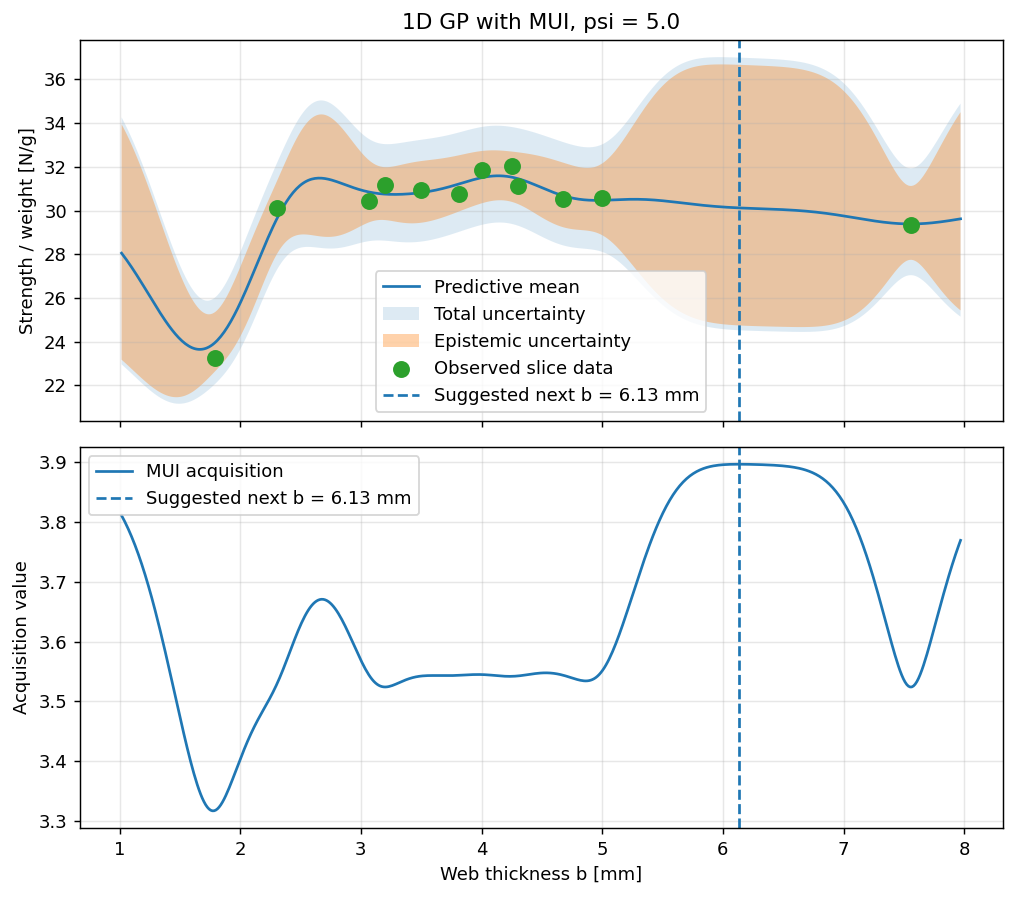

{'method': 'MUI', 'dial': 5.0, 'b_mm': 6.117, 'pred_mean': 30.123665720262558, 'epistemic_std_log': 0.09823654501140558, 'acq': 3.8964938244433855}


In [29]:
psi = 5.0
plot_mui_for_psi(psi)
print(recommend_mui_1d(psi))

In [30]:
mui_scan = pd.DataFrame([recommend_mui_1d(p) for p in [0.0, 0.25, 0.5, 1.0, 1.5, 2.5, 4.0, 5.0, 7.5]])
mui_scan

,method,dial,b_mm,pred_mean,epistemic_std_log,acq
0,MUI,0.00,4.117,31.584223,0.018125,3.452658
1,MUI,0.25,2.667,31.480623,0.044244,3.460433
2,MUI,0.50,2.667,31.480623,0.044244,3.471494
3,MUI,1.00,5.817,30.248476,0.095621,3.505067
4,MUI,1.50,5.917,30.196039,0.097164,3.553457
5,MUI,2.50,6.017,30.154743,0.097913,3.651124
6,MUI,4.00,6.117,30.123666,0.098237,3.798257
7,MUI,5.00,6.117,30.123666,0.098237,3.896494
8,MUI,7.50,6.167,30.111154,0.098314,4.142248


### Question 4
In your memo, explain what changed as you increased `psi`.

In particular:
- Did the next recommended point move toward a stronger predicted region or a more uncertain region?
- Which choice looks more exploratory?
- Which choice looks more exploitative?
- Which `psi` seems most reasonable if each beam test is expensive?

## PART M. A second Bayesian Optimization rule: Expected Improvement

Maximum upper interval is not the only acquisition rule.

Another common rule is **Expected Improvement (EI)**.

The idea is:
- look at the best value observed so far
- estimate how much improvement a new test might produce
- weight that by both predicted performance and epistemic uncertainty

A simple maximization version is

$$
EI(x) = (\mu(x)-y_{best}-\xi)\Phi(Z) + \sigma(x)\phi(Z)
$$

with

$$
Z = \frac{\mu(x)-y_{best}-\xi}{\sigma(x)}.
$$

where:
- $y_{best}$ = best observed value so far in log space
- $\xi$ = an improvement threshold or exploration dial
- $\Phi$ and $\phi$ = standard normal CDF and PDF

In [17]:
def expected_improvement(mu, sigma, y_best, xi=0.0):
    mu = np.asarray(mu)
    sigma = np.asarray(sigma)
    improvement = mu - y_best - xi

    ei = np.zeros_like(mu)
    mask = sigma > 1e-12

    Z = np.zeros_like(mu)
    Z[mask] = improvement[mask] / sigma[mask]

    ei[mask] = improvement[mask] * norm.cdf(Z[mask]) + sigma[mask] * norm.pdf(Z[mask])
    return ei

y_best_1d_log = np.max(np.log(y1))

def recommend_ei_1d(xi):
    acq = expected_improvement(pred1d_cand["mu_z"], pred1d_cand["std_epi_z"], y_best_1d_log, xi=xi)
    idx = np.argmax(acq)
    return {
        "method": "EI",
        "dial": xi,
        "b_mm": float(X1_candidates[idx, 0]),
        "pred_mean": float(pred1d_cand["mean_y"][idx]),
        "epistemic_std_log": float(pred1d_cand["std_epi_z"][idx]),
        "acq": float(acq[idx])
    }

def plot_ei_for_xi(xi):
    acq_plot = expected_improvement(pred1d["mu_z"], pred1d["std_epi_z"], y_best_1d_log, xi=xi)
    idx_plot = np.argmax(acq_plot)
    b_next = float(b_plot[idx_plot, 0])

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axes[0].plot(b_plot, pred1d["mean_y"], label="Predictive mean")
    axes[0].fill_between(
        b_plot.ravel(), pred1d["lo_total_y"], pred1d["hi_total_y"],
        alpha=0.15, label="Total uncertainty"
    )
    axes[0].fill_between(
        b_plot.ravel(), pred1d["lo_epi_y"], pred1d["hi_epi_y"],
        alpha=0.35, label="Epistemic uncertainty"
    )
    axes[0].scatter(X1, y1, s=70, zorder=3, label="Observed slice data")
    axes[0].axvline(b_next, linestyle="--", label=f"Suggested next b = {b_next:.2f} mm")
    axes[0].set_ylabel("Strength / weight [N/g]")
    axes[0].set_title(f"1D GP with EI, xi = {xi}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(b_plot, acq_plot, label="Expected Improvement")
    axes[1].axvline(b_next, linestyle="--", label=f"Suggested next b = {b_next:.2f} mm")
    axes[1].set_xlabel("Web thickness b [mm]")
    axes[1].set_ylabel("Acquisition value")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## PART N. Explore what changes when you change xi in EI

Run the next cells with different values of `xi`.

Suggested values:
- `xi = 0.0`
- `xi = 0.2`
- `xi = 1.0`

These values should help you see that the acquisition rule and the recommendation can change even when the underlying predictive model stays the same.

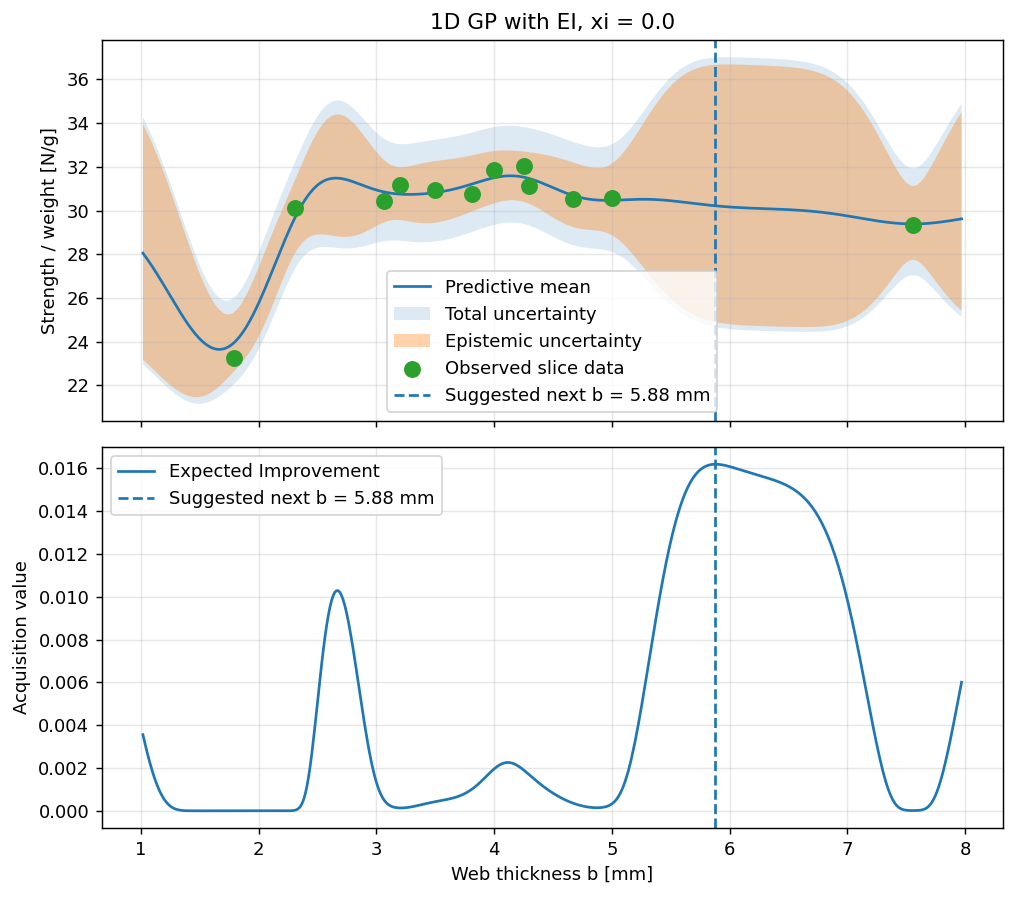

{'method': 'EI', 'dial': 0.0, 'b_mm': 5.867, 'pred_mean': 30.220903755191788, 'epistemic_std_log': 0.09652120110322267, 'acq': 0.016186460590417277}


In [18]:
xi = 0.0
plot_ei_for_xi(xi)
print(recommend_ei_1d(xi))


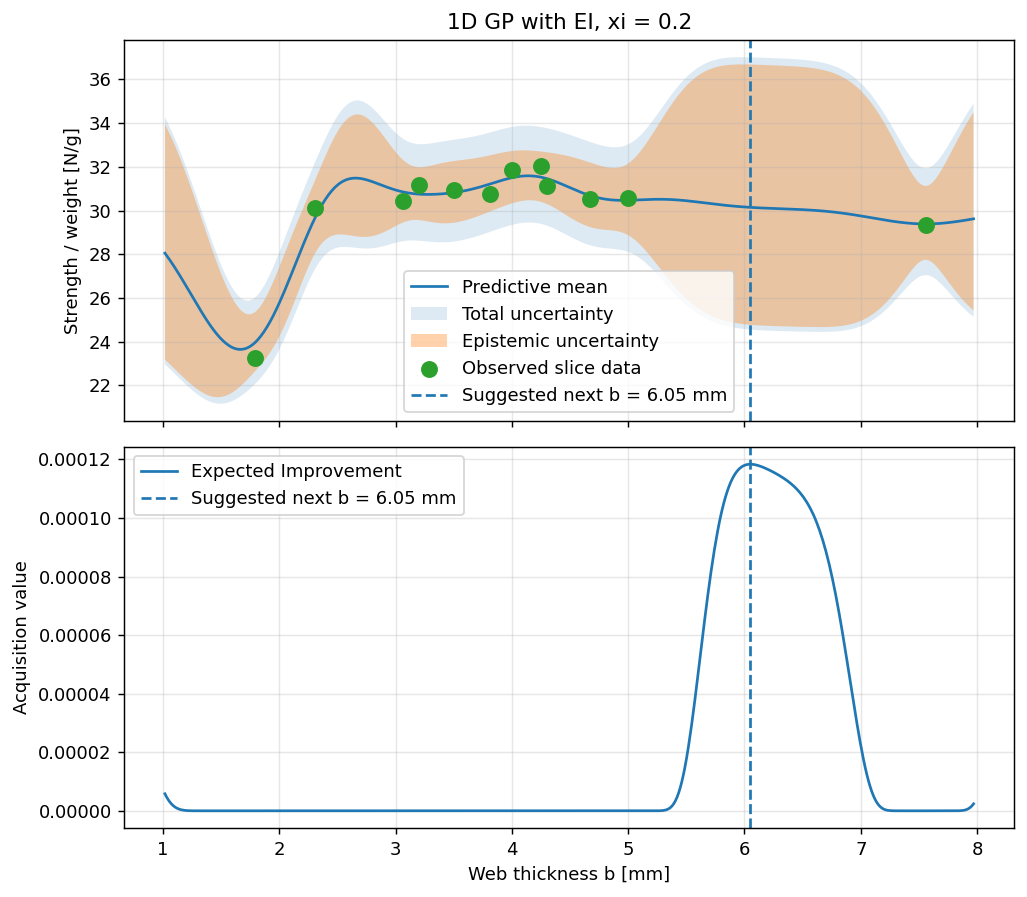

{'method': 'EI', 'dial': 0.2, 'b_mm': 6.067, 'pred_mean': 30.138065901736304, 'epistemic_std_log': 0.09811057282749519, 'acq': 0.00011835583820664353}


In [19]:
xi = 0.2
plot_ei_for_xi(xi)
print(recommend_ei_1d(xi))


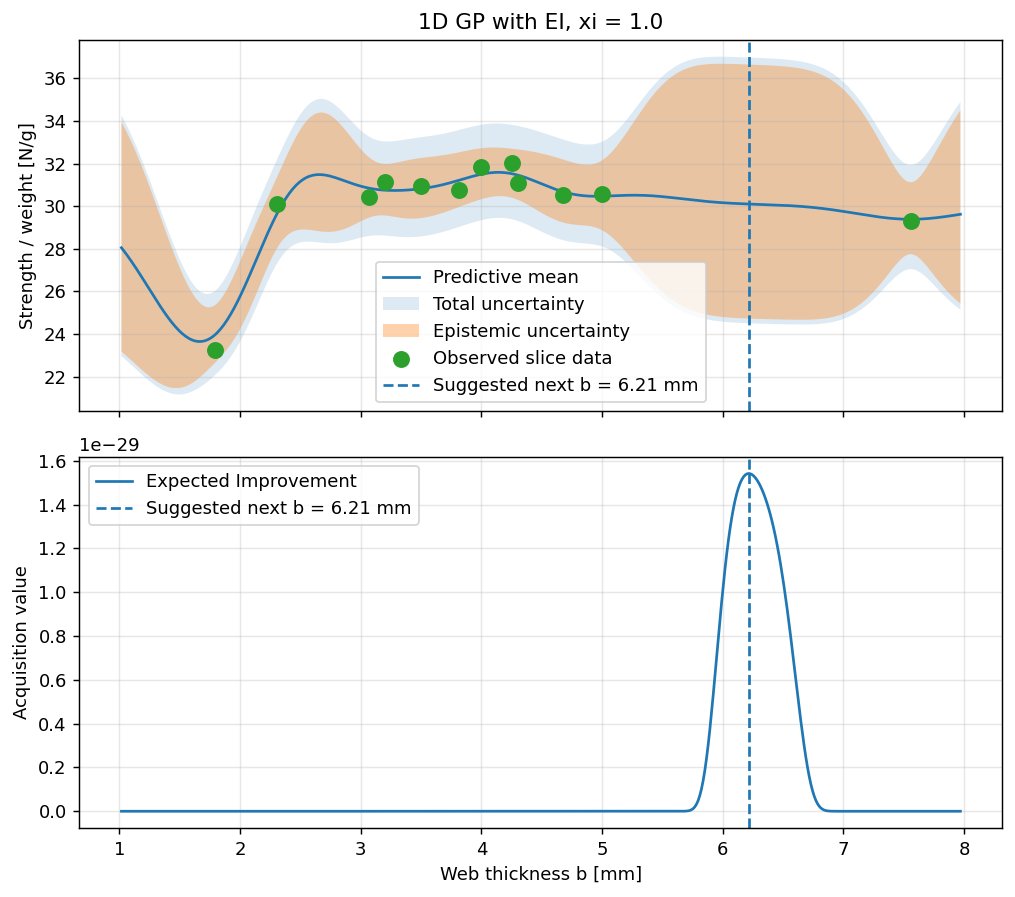

{'method': 'EI', 'dial': 1.0, 'b_mm': 6.217, 'pred_mean': 30.100081599313093, 'epistemic_std_log': 0.0983578906183129, 'acq': 1.542076146719451e-29}


In [20]:
xi = 1.0
plot_ei_for_xi(xi)
print(recommend_ei_1d(xi))


In [21]:
ei_scan = pd.DataFrame([recommend_ei_1d(xi) for xi in [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.0, 1.5]])
ei_scan


,method,dial,b_mm,pred_mean,epistemic_std_log,acq
0,EI,0.00,5.867,30.220904,0.096521,1.618646e-02
1,EI,0.05,5.917,30.196039,0.097164,6.374415e-03
2,EI,0.10,5.967,30.174003,0.097611,2.076974e-03
3,EI,0.20,6.067,30.138066,0.098111,1.183558e-04
4,EI,0.40,6.117,30.123666,0.098237,2.545593e-08
5,EI,0.80,6.217,30.100082,0.098358,1.007902e-20
6,EI,1.00,6.217,30.100082,0.098358,1.542076e-29
7,EI,1.50,6.267,30.089961,0.098380,2.538717e-59


### Question 5
In your memo, compare MUI and EI.

Questions to address:
- Do they recommend the same next point?
- Which one seems easier to interpret?
- Which dial (`psi` or `xi`) feels more intuitive to you as an engineer?
- If the recommendations differ, what is each method valuing?

## PART O. Step back to the full 2D beam-design problem

The real beam problem is not one-dimensional.  
We ultimately want to choose a beam using more than one design variable.

Below, we fit a simple 2D GP using the available beam data:
- input 1 = `b_mm`
- input 2 = `H_mm`
- output = `strength_to_weight`

This is still only a first-pass predictive model, but it is closer to the full design problem.

In [22]:
X2 = beam_data[["b_mm", "H_mm"]].values.astype(float)
y2 = beam_data["strength_to_weight"].values.astype(float)

def fit_log_gp_2d(X, y, rel_noise):
    z = np.log(y)
    z_mean = z.mean()
    z_centered = z - z_mean

    alpha = rel_noise**2

    kernel = C(1.0, (1e-3, 1e3)) * RBF(
        length_scale=[1.0, 2.0],
        length_scale_bounds=(1e-2, 20.0)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha,
        normalize_y=False,
        random_state=0,
        n_restarts_optimizer=5
    )
    gp.fit(X, z_centered)
    return gp, z_mean

baseline_noise_frac_2d = 0.03
gp2d, zmean2d = fit_log_gp_2d(X2, y2, rel_noise=baseline_noise_frac_2d)

b_grid = np.arange(float(beam_data["b_mm"].min()), float(beam_data["b_mm"].max()) + 0.125, 0.25)
H_grid = np.arange(float(beam_data["H_mm"].min()), float(beam_data["H_mm"].max()) + 0.125, 0.25)
BB, HH = np.meshgrid(b_grid, H_grid)
X_grid_all = np.column_stack([BB.ravel(), HH.ravel()])

# Exclude already-tested points from recommendations
keep = []
for pt in X_grid_all:
    d = np.sqrt(np.sum((X2 - pt)**2, axis=1))
    if np.min(d) > 0.15:
        keep.append(pt)
X_grid = np.array(keep)

pred2d_all = predict_log_gp(gp2d, zmean2d, X_grid_all, rel_noise=baseline_noise_frac_2d)
pred2d_cand = predict_log_gp(gp2d, zmean2d, X_grid, rel_noise=baseline_noise_frac_2d)

print("Learned 2D kernel:")
print(gp2d.kernel_)

Learned 2D kernel:
0.725**2 * RBF(length_scale=[2.17, 8.82])


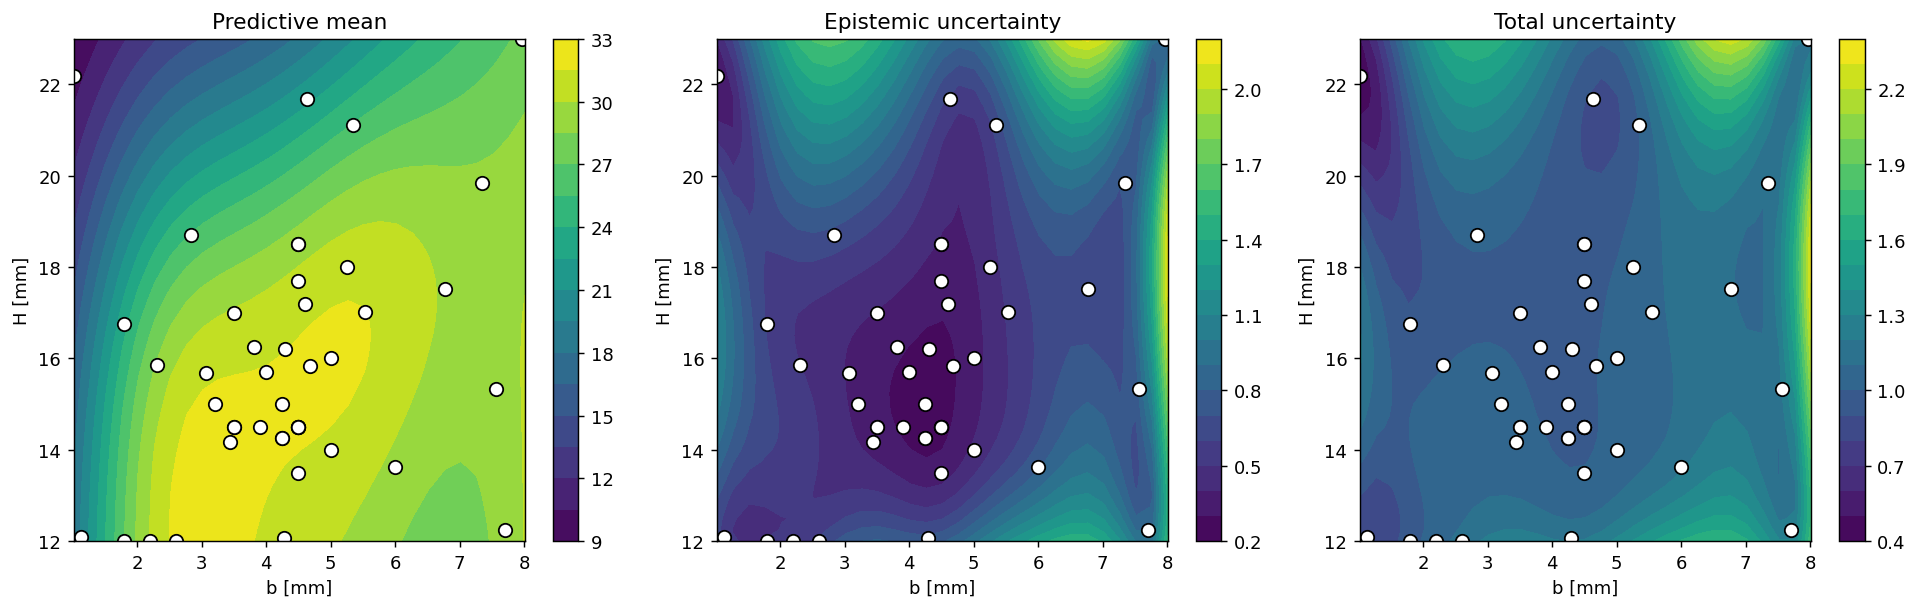

In [23]:
MU2 = pred2d_all["mean_y"].reshape(BB.shape)
EPI2_WIDTH = ((pred2d_all["hi_epi_y"] - pred2d_all["lo_epi_y"]) / 4.0).reshape(BB.shape)
TOT2_WIDTH = ((pred2d_all["hi_total_y"] - pred2d_all["lo_total_y"]) / 4.0).reshape(BB.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

cf1 = axes[0].contourf(BB, HH, MU2, levels=20)
axes[0].scatter(beam_data["b_mm"], beam_data["H_mm"], c="white", edgecolor="black", s=55)
axes[0].set_xlabel("b [mm]")
axes[0].set_ylabel("H [mm]")
axes[0].set_title("Predictive mean")
fig.colorbar(cf1, ax=axes[0])

cf2 = axes[1].contourf(BB, HH, EPI2_WIDTH, levels=20)
axes[1].scatter(beam_data["b_mm"], beam_data["H_mm"], c="white", edgecolor="black", s=55)
axes[1].set_xlabel("b [mm]")
axes[1].set_ylabel("H [mm]")
axes[1].set_title("Epistemic uncertainty")
fig.colorbar(cf2, ax=axes[1])

cf3 = axes[2].contourf(BB, HH, TOT2_WIDTH, levels=20)
axes[2].scatter(beam_data["b_mm"], beam_data["H_mm"], c="white", edgecolor="black", s=55)
axes[2].set_xlabel("b [mm]")
axes[2].set_ylabel("H [mm]")
axes[2].set_title("Total uncertainty")
fig.colorbar(cf3, ax=axes[2])

plt.tight_layout()
plt.show()


## PART P. Compare 2D recommendations with different exploration/exploitation dials

The cells below build recommendation tables in 2D so you can see whether the acquisition rule changes the suggested next beam.

Because the recommendation grid excludes already-tested points and uses a practical grid spacing, the dial changes should produce more meaningful differences than a purely continuous max on a very fine grid.

In [31]:
mu2_cand_log = pred2d_cand["mu_z"]
std2_cand_epi_log = pred2d_cand["std_epi_z"]
y_best_2d_log = np.max(np.log(y2))

def recommend_mui_2d(psi):
    acq = mui(mu2_cand_log, std2_cand_epi_log, psi)
    idx = np.argmax(acq)
    return {
        "method": "MUI",
        "dial": psi,
        "b_mm": float(X_grid[idx, 0]),
        "H_mm": float(X_grid[idx, 1]),
        "pred_mean": float(pred2d_cand["mean_y"][idx]),
        "epistemic_std_log": float(pred2d_cand["std_epi_z"][idx]),
        "acq": float(acq[idx])
    }

def recommend_ei_2d(xi):
    acq = expected_improvement(mu2_cand_log, std2_cand_epi_log, y_best_2d_log, xi=xi)
    idx = np.argmax(acq)
    return {
        "method": "EI",
        "dial": xi,
        "b_mm": float(X_grid[idx, 0]),
        "H_mm": float(X_grid[idx, 1]),
        "pred_mean": float(pred2d_cand["mean_y"][idx]),
        "epistemic_std_log": float(pred2d_cand["std_epi_z"][idx]),
        "acq": float(acq[idx])
    }

mui_2d_scan = pd.DataFrame([recommend_mui_2d(p) for p in [0.0, 0.5, 1.0, 2.0, 4.0]])
ei_2d_scan  = pd.DataFrame([recommend_ei_2d(xi) for xi in [0.0, 0.1, 0.3, 0.6, 1.0]])

print("MUI recommendations")
display(mui_2d_scan)

print("EI recommendations")
display(ei_2d_scan)

MUI recommendations


,method,dial,b_mm,H_mm,pred_mean,epistemic_std_log,acq
0,MUI,0.0,3.017,12.75,32.290264,0.017167,3.474766
1,MUI,0.5,3.017,12.00,32.269358,0.023279,3.485757
2,MUI,1.0,3.017,12.00,32.269358,0.023279,3.497397
3,MUI,2.0,8.017,17.50,29.984038,0.070356,3.541378
4,MUI,4.0,8.017,17.75,29.941477,0.070815,3.682505


EI recommendations


,method,dial,b_mm,H_mm,pred_mean,epistemic_std_log,acq
0,EI,0.0,8.017,17.25,30.020242,0.069723,3.407913e-03
1,EI,0.1,8.017,17.50,29.984038,0.070356,7.618572e-05
2,EI,0.3,8.017,17.75,29.941477,0.070815,2.046226e-10
3,EI,0.6,8.017,18.00,29.892235,0.071081,7.036574e-25
4,EI,1.0,6.767,23.00,24.899131,0.085059,2.274621e-53


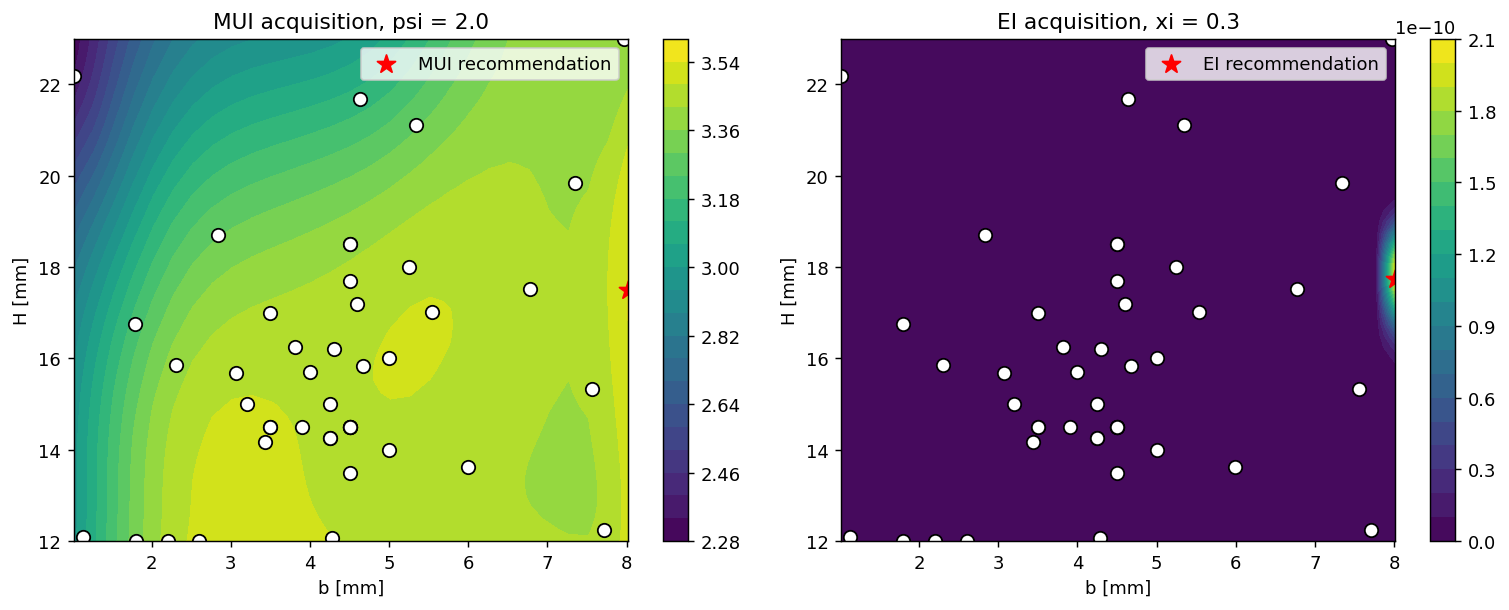

MUI recommendation: b=8.02 mm, H=17.50 mm
EI recommendation:  b=8.02 mm, H=17.75 mm


In [32]:
psi_2d = 2.0
xi_2d = 0.3

acq_mui_all = mui(pred2d_all["mu_z"], pred2d_all["std_epi_z"], psi_2d).reshape(BB.shape)
acq_ei_all = expected_improvement(pred2d_all["mu_z"], pred2d_all["std_epi_z"], y_best_2d_log, xi=xi_2d).reshape(BB.shape)

idx_mui = np.argmax(mui(mu2_cand_log, std2_cand_epi_log, psi_2d))
b_mui, H_mui = X_grid[idx_mui]

idx_ei = np.argmax(expected_improvement(mu2_cand_log, std2_cand_epi_log, y_best_2d_log, xi=xi_2d))
b_ei, H_ei = X_grid[idx_ei]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

cf1 = axes[0].contourf(BB, HH, acq_mui_all, levels=20)
axes[0].scatter(beam_data["b_mm"], beam_data["H_mm"], c="white", edgecolor="black", s=55)
axes[0].scatter([b_mui], [H_mui], c="red", s=110, marker="*", label="MUI recommendation")
axes[0].set_xlabel("b [mm]")
axes[0].set_ylabel("H [mm]")
axes[0].set_title(f"MUI acquisition, psi = {psi_2d}")
axes[0].legend()
fig.colorbar(cf1, ax=axes[0])

cf2 = axes[1].contourf(BB, HH, acq_ei_all, levels=20)
axes[1].scatter(beam_data["b_mm"], beam_data["H_mm"], c="white", edgecolor="black", s=55)
axes[1].scatter([b_ei], [H_ei], c="red", s=110, marker="*", label="EI recommendation")
axes[1].set_xlabel("b [mm]")
axes[1].set_ylabel("H [mm]")
axes[1].set_title(f"EI acquisition, xi = {xi_2d}")
axes[1].legend()
fig.colorbar(cf2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"MUI recommendation: b={b_mui:.2f} mm, H={H_mui:.2f} mm")
print(f"EI recommendation:  b={b_ei:.2f} mm, H={H_ei:.2f} mm")

### Question 6
In your memo, identify:
- one region that looks strong by predictive mean
- one region that looks attractive because the model is epistemically uncertain
- whether MUI and EI recommend the same beam
- whether your final recommended beam seems more exploratory or exploitative

## PART Q. Choose your first beam to test

Avoid assuming the computer found the true best beam. The predictive model suggests a useful next beam to test given current data and uncertainty.

For your final recommendation, ask:
- Is the suggested beam in a strong predicted region?
- Does it teach us something important?
- Would a nearby alternative work better?
- What assumptions in the predictive model might fail?

Write down your recommended first beam:
- **Recommended b** = ______ mm
- **Recommended H** = ______ mm

## PART R. Final memo questions for submission

Use figures from this notebook in your memo. In addition to Questions 1-6 above, address the following:

**Question 7.** What is the difference between epistemic and aleatory uncertainty?

**Question 8.** What sources of noise and variability matter in this lab?

**Question 9.** Why is maximizing only the predictive mean a poor next-test strategy?

**Question 10.** What assumptions or limitations should we keep in mind before trusting this recommendation?